# Clustering and Initialization project

## Synthetic data

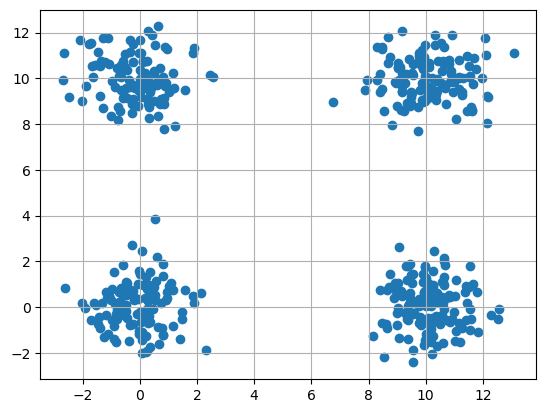

In [1]:
import numpy as np
import matplotlib.pyplot as plt


rng = np.random.RandomState(42)
n = 500

sizes = rng.multinomial(500, [1/4, 1/4, 1/4, 1/4])
n1, n2, n3, n4 = sizes


mean1 = [0, 0]
mean2 = [10, 10]
mean3 = [0, 10]
mean4 = [10, 0]

c1 = rng.randn(n1, 2) + mean1
c2 = rng.randn(n2, 2) + mean2
c3 = rng.randn(n3, 2) + mean3
c4 = rng.randn(n4, 2) + mean4

X_synth = np.vstack((c1, c2, c3, c4))

plt.scatter(X_synth[:, 0], X_synth[:, 1])
plt.grid(True)
plt.show()


## Real world data - MNIST dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data.astype(np.float64)
X = X / 255.0  # normalizing the data
y = mnist.target.astype(int)

# subsetting mnist to work with a more manageable size
rng_mnist = np.random.RandomState(42)
subset_size = 2000

indices = rng_mnist.choice(X.shape[0], subset_size, replace=False)
X_subset = X[indices]
y_subset = y[indices]
X = X_subset
y = y_subset

print(X.shape)
print(y.shape)

(2000, 784)
(2000,)


## kmeans function

In [3]:
# helper functions

def get_labels(X, centroids):
    distances = []

    for centroid in centroids:
        dist = np.sum((X - centroid) ** 2, axis=1)
        distances.append(dist)
    distances = np.array(distances).T

    return np.argmin(distances, axis=1)

def new_centroids(X, labels, k):
    n_features = X.shape[1]
    centroids = np.zeros((k, n_features))

    for i in range(k):
        cluster_points = X[labels == i]
        if len(cluster_points) == 0:
            centroids[i] = X[np.random.randint(X.shape[0])]
        else:
            centroids[i] = cluster_points.mean(axis=0)

    return centroids


In [4]:
# centroid initialization functions

# base kmeans:

def random_centroids(X, k):
    
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

# kmeans++:

def plus_plus_centroids(X, k):
    n = X.shape[0]

    centroids = []
    chosen_indices = set()

    first_idx = np.random.randint(n)
    centroids.append(X[first_idx])
    chosen_indices.add(first_idx)

    for _ in range(k - 1):
        dist_sq = np.min(
            np.sum(
                (X[:, np.newaxis] - np.array(centroids)) ** 2,
                axis=2
            ),
            axis=1
        )
        probs = dist_sq / dist_sq.sum()

        # avoiding duplicates
        while True:
            next_idx = np.random.choice(n, p=probs)

            if next_idx not in chosen_indices:
                chosen_indices.add(next_idx)
                break

        centroids.append(X[next_idx])

    return np.array(centroids)

In [5]:
#kmeans final function

def kmeans(X, k, init = "random"):

    if(init == "random"):
        centroids = random_centroids(X,k)
    elif(init == "++"):
        centroids = plus_plus_centroids(X, k)

    for iteration in range(100):

        old_centroids = centroids.copy()
        labels = get_labels(X, centroids)
        centroids = new_centroids(X, labels, k)

        if np.allclose(centroids, old_centroids):
            break

    return labels, centroids, iteration +1

## Calculating inertia

In [6]:
def compute_inertia(X, labels, centroids):
    inertia = 0
    
    for i in range(len(X)):
        centroid = centroids[labels[i]]
        inertia += np.sum((X[i] - centroid) ** 2)
    
    return inertia 

## Running repearted trials to calculate variance in results

In [7]:
def kmeans_trials(X, k, n_trials):
    
    inertias = []
    iterations_list = []
    
    for i in range(n_trials):
        
        np.random.seed(i)
        labels, centroids, iterations = kmeans(X, k)
        inertia = compute_inertia(X, labels, centroids)
        inertias.append(inertia)
        iterations_list.append(iterations)
        
    return inertias, iterations_list

def kmeans_plus_plus_trials(X, k, n_trials):
    
    inertias = []
    iterations_list = []
    
    for i in range(n_trials):
        
        np.random.seed(i)
        labels, centroids, iterations = kmeans(X, k, "++")
        inertia = compute_inertia(X, labels, centroids)
        inertias.append(inertia)
        iterations_list.append(iterations)
        
    return inertias, iterations_list

In [8]:
def iteration_trials(X, k, trials, init):
    
    iterations_list = []
    
    for i in range(trials):
        
        np.random.seed(i)
        labels, centroids, iterations = kmeans(X, k, init)
        iterations_list.append(iterations)
        
    return iterations_list

## Running multiple trials

In [9]:
# running multiple (100) trials on synthetic data
# base kmeans

inertias_synth, iterations_synth = kmeans_trials(X_synth, 4, 100)
inertias_synth_pp, iterations_synth_pp = kmeans_plus_plus_trials(X_synth, 4, 100)

In [10]:
print("KMEANS")
print("mean:", np.mean(inertias_synth))
print("best:", np.min(inertias_synth))
print("worst:", np.max(inertias_synth))
print("std:", np.std(inertias_synth))
print("mean iterations:", np.mean(iterations_synth))

print()

print("KMEANS++")
print("mean:", np.mean(inertias_synth_pp))
print("best:", np.min(inertias_synth_pp))
print("worst:", np.max(inertias_synth_pp))
print("std:", np.std(inertias_synth_pp))
print("mean iterations:", np.mean(iterations_synth_pp))

KMEANS
mean: 3441.029503369609
best: 949.7007266396834
worst: 7599.088659262058
std: 2998.164307838755
mean iterations: 5.76

KMEANS++
mean: 1199.823358989871
best: 949.7007266396834
worst: 7574.609363956282
std: 1227.4877000389763
mean iterations: 2.71


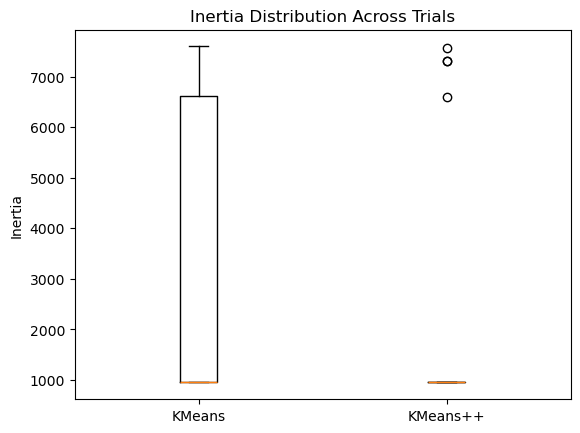

In [11]:
plt.boxplot([inertias_synth, inertias_synth_pp],
            tick_labels=["KMeans", "KMeans++"])

plt.ylabel("Inertia")
plt.title("Inertia Distribution Across Trials")
plt.show()

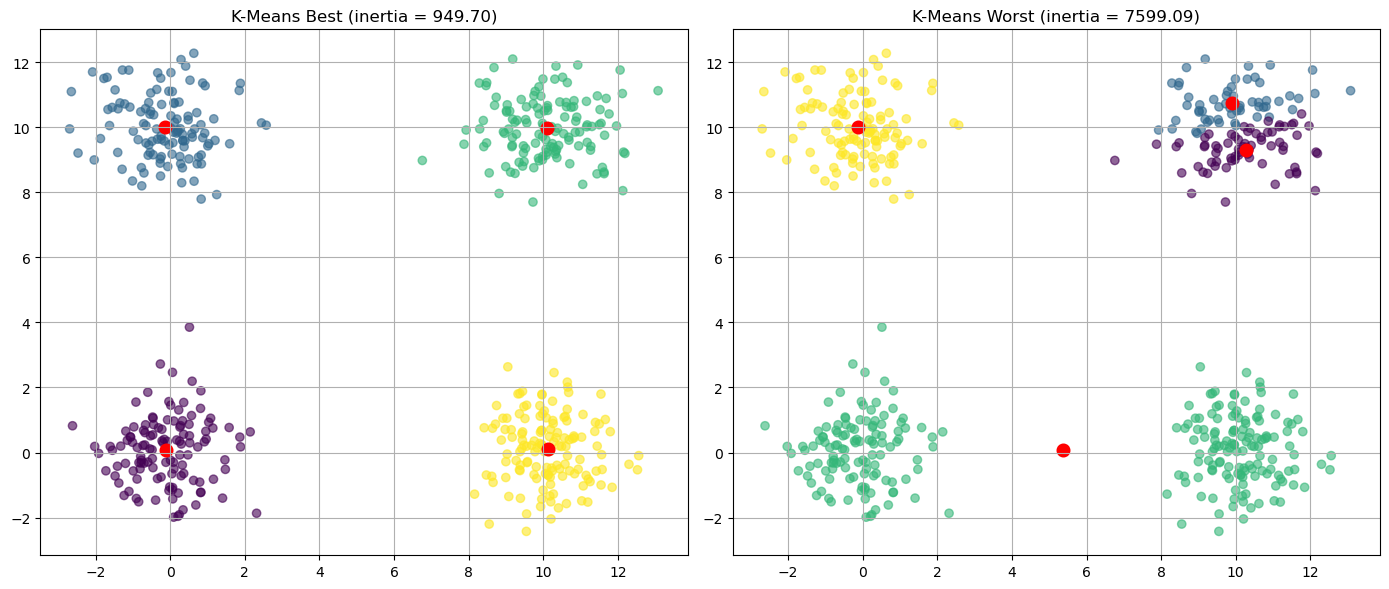

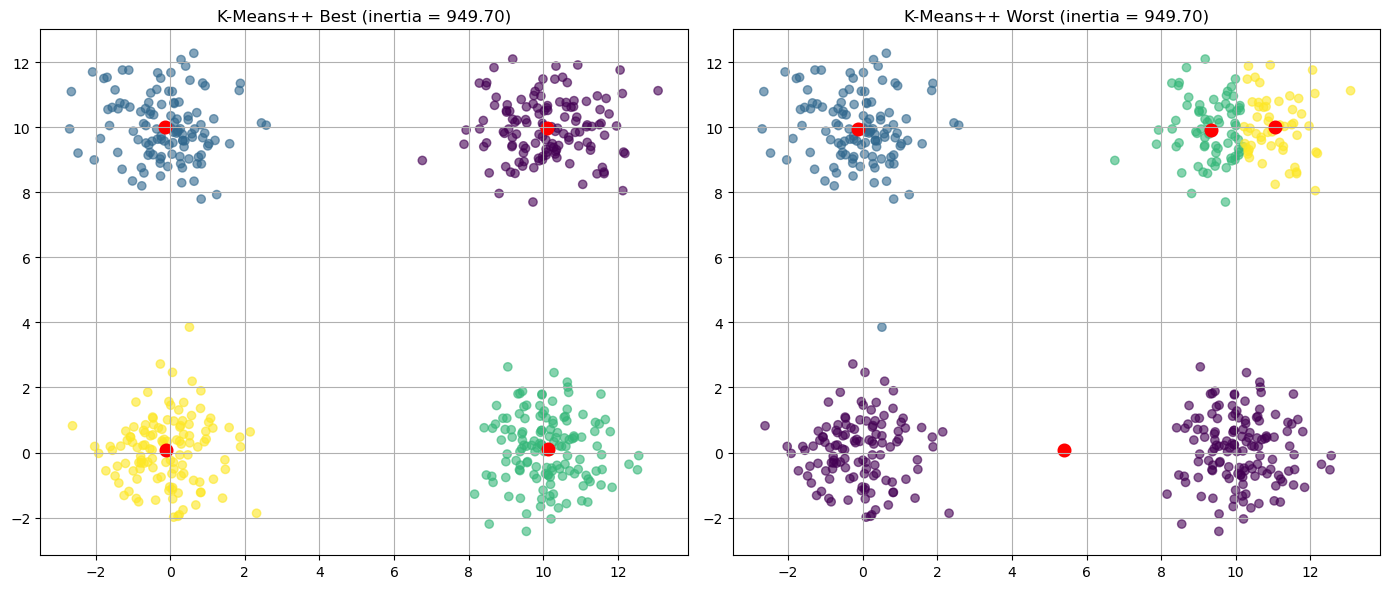

In [12]:
# kmeans best and worst
best_idx_km = np.argmin(inertias_synth)
worst_idx_km = np.argmax(inertias_synth)

np.random.seed(best_idx_km)
labels_best_km, centroids_best_km, _ = kmeans(X_synth, 4)

np.random.seed(worst_idx_km)
labels_worst_km, centroids_worst_km, _ = kmeans(X_synth, 4)

# kmeans++ best and worst
best_idx_pp = np.argmin(inertias_synth_pp)
worst_idx_pp = np.argmax(inertias_synth_pp)

np.random.seed(best_idx_pp)
labels_best_pp, centroids_best_pp, _ = kmeans(X_synth, 4, "++")

np.random.seed(worst_idx_pp)
labels_worst_pp, centroids_worst_pp, _ = kmeans(X_synth, 4, "++")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_synth[:, 0], X_synth[:, 1], c=labels_best_km, alpha=0.6)
axes[0].scatter(centroids_best_km[:, 0], centroids_best_km[:, 1], color='red', marker='.', s=200, linewidths=3)
axes[0].set_title(f'K-Means Best (inertia = {inertias_synth[best_idx_km]:.2f})')
axes[0].grid(True)

axes[1].scatter(X_synth[:, 0], X_synth[:, 1], c=labels_worst_km, alpha=0.6)
axes[1].scatter(centroids_worst_km[:, 0], centroids_worst_km[:, 1], color='red', marker='.', s=200, linewidths=3)
axes[1].set_title(f'K-Means Worst (inertia = {inertias_synth[worst_idx_km]:.2f})')
axes[1].grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_synth[:, 0], X_synth[:, 1], c=labels_best_pp, alpha=0.6)
axes[0].scatter(centroids_best_pp[:, 0], centroids_best_pp[:, 1], color='red', marker='.', s=200, linewidths=3)
axes[0].set_title(f'K-Means++ Best (inertia = {inertias_synth_pp[best_idx_pp]:.2f})')
axes[0].grid(True)

axes[1].scatter(X_synth[:, 0], X_synth[:, 1], c=labels_worst_pp, alpha=0.6)
axes[1].scatter(centroids_worst_pp[:, 0], centroids_worst_pp[:, 1], color='red', marker='.', s=200, linewidths=3)
axes[1].set_title(f'K-Means++ Worst (inertia = {inertias_synth_pp[best_idx_pp]:.2f})')
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [13]:
# running multiple (50) trails on real data

inertias_real, iterations_real = kmeans_trials(X, 10, 50)
inertias_real_pp, iterations_real_pp = kmeans_plus_plus_trials(X, 10, 50)

In [14]:
print("KMEANS")
print("mean:", np.mean(inertias_real))
print("best:", np.min(inertias_real))
print("worst:", np.max(inertias_real))
print("std:", np.std(inertias_real))
print("mean iterations:", np.mean(iterations_real))

print()

print("KMEANS++")
print("mean:", np.mean(inertias_real_pp))
print("best:", np.min(inertias_real_pp))
print("worst:", np.max(inertias_real_pp))
print("std:", np.std(inertias_real_pp))
print("mean iterations:", np.mean(iterations_real_pp))

KMEANS
mean: 78461.26802376227
best: 77983.11369147607
worst: 79594.43674717117
std: 313.93979291480537
mean iterations: 29.68

KMEANS++
mean: 78433.25303415017
best: 77988.54851606934
worst: 79025.3398833712
std: 265.77290610201146
mean iterations: 29.72


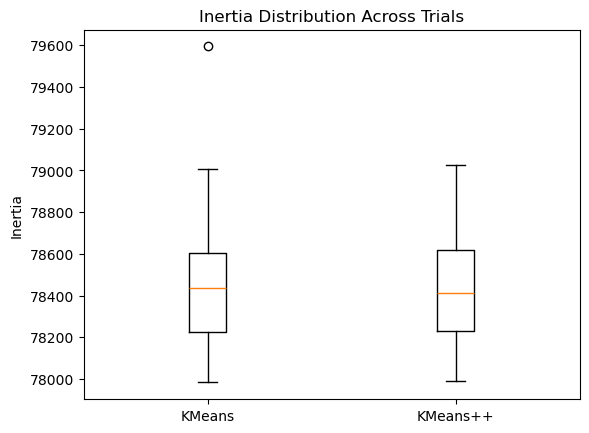

In [15]:
plt.boxplot([inertias_real, inertias_real_pp],
            tick_labels=["KMeans", "KMeans++"])

plt.ylabel("Inertia")
plt.title("Inertia Distribution Across Trials")
plt.show()

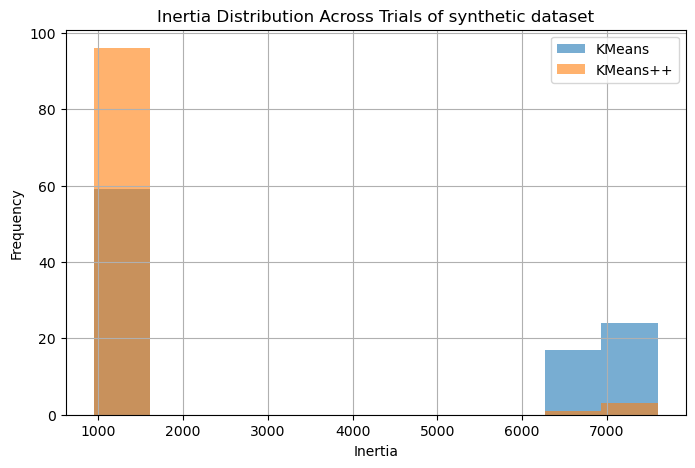

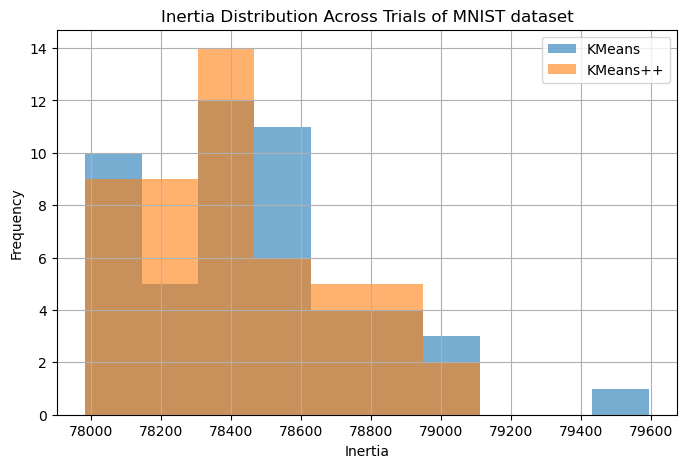

In [23]:
# synthetic
bins_synth = np.linspace(min(min(inertias_synth), min(inertias_synth_pp)),
                         max(max(inertias_synth), max(inertias_synth_pp)),
                         11)

plt.figure(figsize=(8, 5))
plt.hist(inertias_synth,
         bins=bins_synth,
         alpha=0.6,
         label="KMeans")
plt.hist(inertias_synth_pp,
         bins=bins_synth,
         alpha=0.6,
         label="KMeans++")
plt.xlabel("Inertia")
plt.ylabel("Frequency")
plt.title("Inertia Distribution Across Trials of synthetic dataset")
plt.legend()
plt.grid(True)
plt.show()

# MNIST
bins_real = np.linspace(min(min(inertias_real), min(inertias_real_pp)),
                        max(max(inertias_real), max(inertias_real_pp)),
                        11)

plt.figure(figsize=(8, 5))
plt.hist(inertias_real,
         bins=bins_real,
         alpha=0.6,
         label="KMeans")
plt.hist(inertias_real_pp,
         bins=bins_real,
         alpha=0.6,
         label="KMeans++")
plt.xlabel("Inertia")
plt.ylabel("Frequency")
plt.title("Inertia Distribution Across Trials of MNIST dataset")
plt.legend()
plt.grid(True)
plt.show()

## Overlapping clusters 

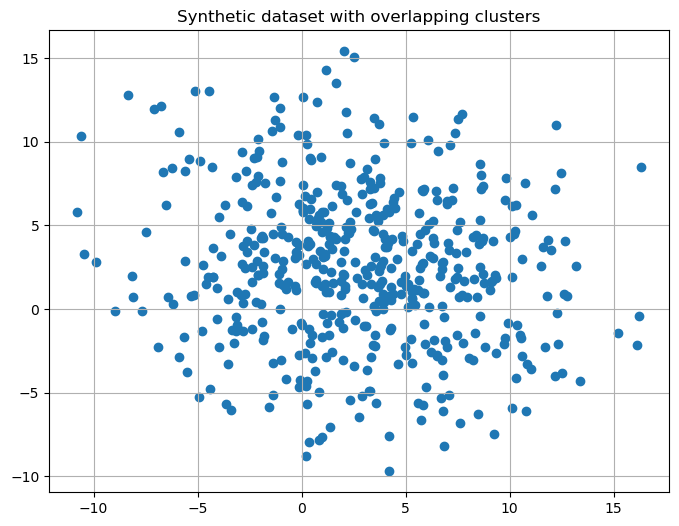

In [24]:
rng_overlap = np.random.RandomState(42)

mean1_ov = [0, 0]
mean2_ov = [4, 4]
mean3_ov = [0, 6]
mean4_ov = [6, 0]
sigma = 4.0

sizes_overlap = rng_overlap.multinomial(500, [1/4, 1/4, 1/4, 1/4])
n1, n2, n3, n4 = sizes_overlap

c1_ov = rng_overlap.randn(n1, 2) * sigma + mean1_ov
c2_ov = rng_overlap.randn(n2, 2) * sigma + mean2_ov
c3_ov = rng_overlap.randn(n3, 2) * sigma + mean3_ov
c4_ov = rng_overlap.randn(n4, 2) * sigma + mean4_ov

X_overlap = np.vstack((c1_ov, c2_ov, c3_ov, c4_ov))

plt.figure(figsize=(8, 6))
plt.scatter(X_overlap[:, 0], X_overlap[:, 1])
plt.grid(True)
plt.title("Synthetic dataset with overlapping clusters")
plt.show()

In [25]:
inertias_km_overlap, iters_km_overlap = kmeans_trials(X_overlap, 4, 100)
inertias_kpp_overlap, iters_kpp_overlap = kmeans_plus_plus_trials(X_overlap, 4, 100)


In [26]:
print("KMEANS")
print(f"mean: {np.mean(inertias_km_overlap)}")
print(f"best: {np.min(inertias_km_overlap)}")
print(f"worst: {np.max(inertias_km_overlap)}")
print(f"std: {np.std(inertias_km_overlap)}")
print(f"mean iterations: {np.mean(iters_km_overlap)}")

print("\nKMEANS++")
print(f"mean: {np.mean(inertias_kpp_overlap)}")
print(f"best: {np.min(inertias_kpp_overlap)}")
print(f"worst: {np.max(inertias_kpp_overlap)}")
print(f"std: {np.std(inertias_kpp_overlap)}")
print(f"mean iterations: {np.mean(iters_kpp_overlap)}")

KMEANS
mean: 8067.872976694228
best: 7938.466152450426
worst: 9365.084866868328
std: 188.91799332233472
mean iterations: 16.44

KMEANS++
mean: 8049.619152506148
best: 7938.3400067807725
worst: 8661.448259353503
std: 116.4780431281309
mean iterations: 17.51


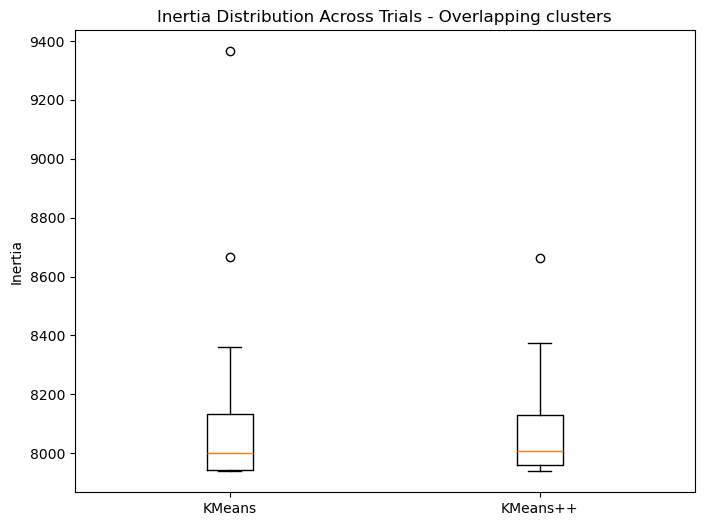

In [27]:
plt.figure(figsize=(8, 6))
plt.boxplot([inertias_km_overlap, inertias_kpp_overlap],
            tick_labels=["KMeans", "KMeans++"])
plt.ylabel("Inertia")
plt.title("Inertia Distribution Across Trials - Overlapping clusters")
plt.show()

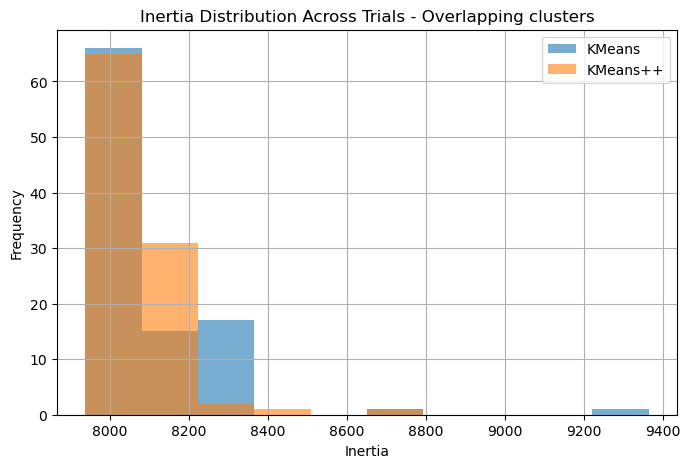

In [28]:
#setting bins to make sure the bars are the same width
bins = np.linspace(min(min(inertias_km_overlap), min(inertias_kpp_overlap)),
                   max(max(inertias_km_overlap), max(inertias_kpp_overlap)),
                   11)

plt.figure(figsize=(8, 5))
plt.hist(inertias_km_overlap,
         bins=bins,
         alpha=0.6,
         label="KMeans")
plt.hist(inertias_kpp_overlap,
         bins=bins,
         alpha=0.6,
         label="KMeans++")
plt.xlabel("Inertia")
plt.ylabel("Frequency")
plt.title("Inertia Distribution Across Trials - Overlapping clusters")
plt.legend()
plt.grid(True)
plt.show()

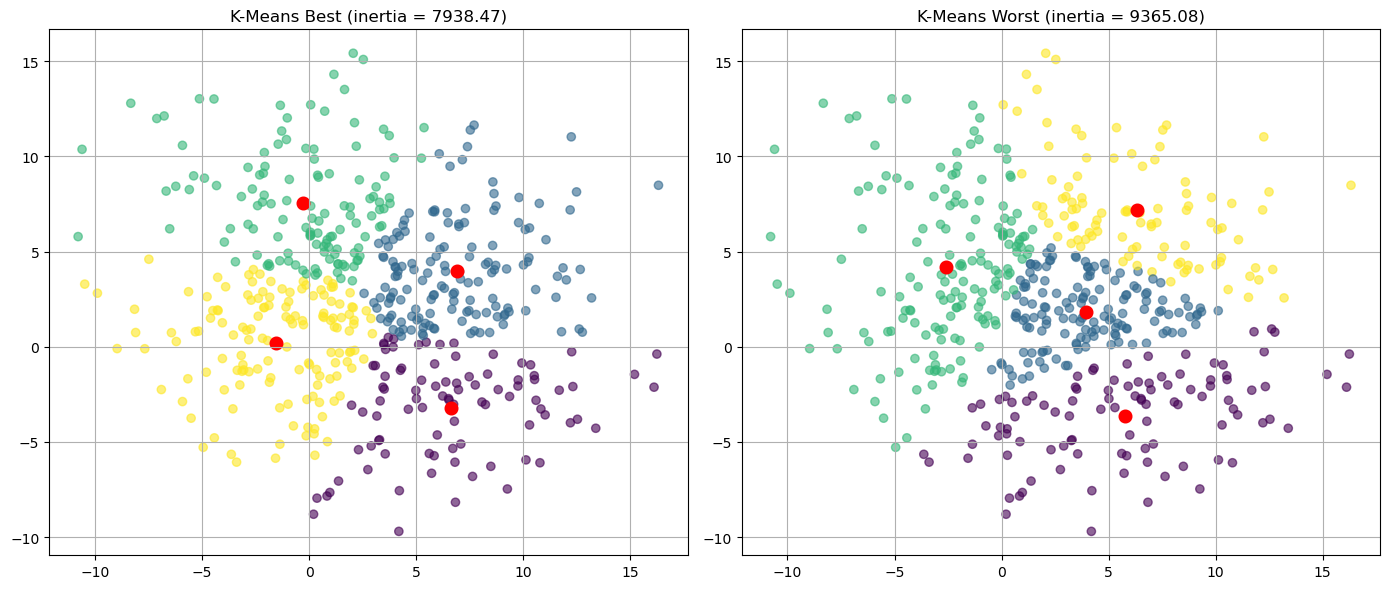

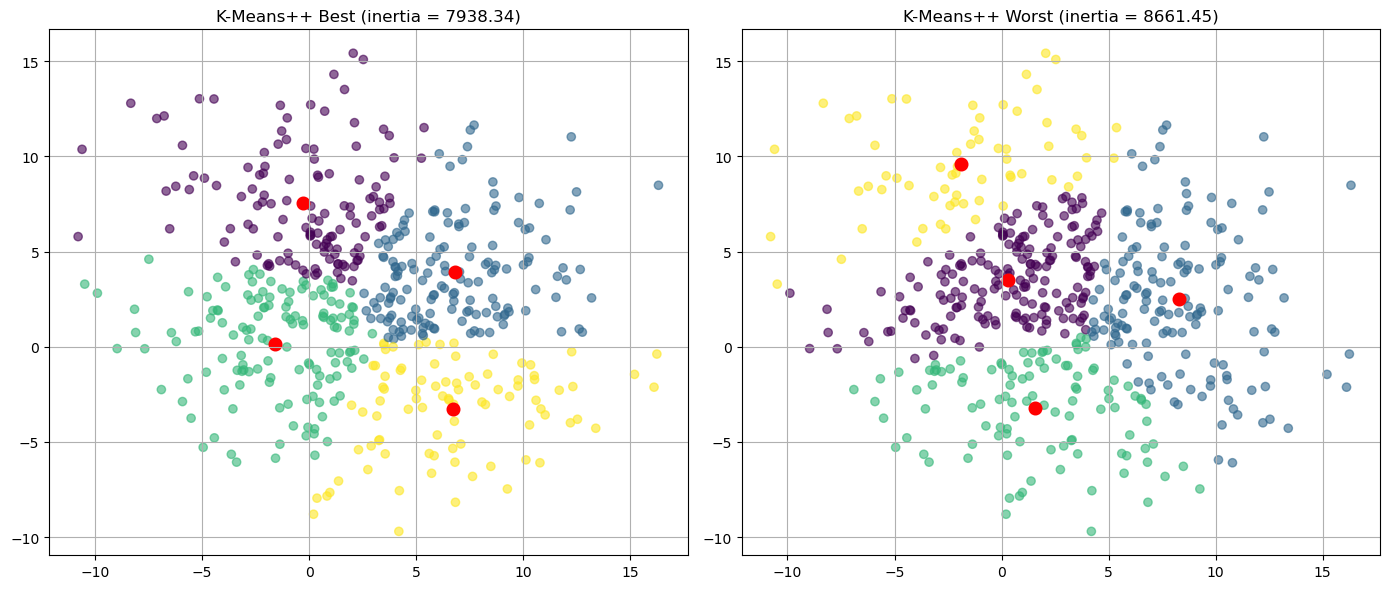

In [29]:
# kmeans best and worst
best_idx_km = np.argmin(inertias_km_overlap)
worst_idx_km = np.argmax(inertias_km_overlap)

np.random.seed(best_idx_km)
labels_best_km, centroids_best_km, _ = kmeans(X_overlap, 4)

np.random.seed(worst_idx_km)
labels_worst_km, centroids_worst_km, _ = kmeans(X_overlap, 4)

# kmeans++ best and worst
best_idx_pp = np.argmin(inertias_kpp_overlap)
worst_idx_pp = np.argmax(inertias_kpp_overlap)

np.random.seed(best_idx_pp)
labels_best_pp, centroids_best_pp, _ = kmeans(X_overlap, 4, "++")

np.random.seed(worst_idx_pp)
labels_worst_pp, centroids_worst_pp, _ = kmeans(X_overlap, 4, "++")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_overlap[:, 0], X_overlap[:, 1], c=labels_best_km, alpha=0.6)
axes[0].scatter(centroids_best_km[:, 0], centroids_best_km[:, 1], color='red', marker='.', s=200, linewidths=3)
axes[0].set_title(f'K-Means Best (inertia = {inertias_km_overlap[best_idx_km]:.2f})')
axes[0].grid(True)

axes[1].scatter(X_overlap[:, 0], X_overlap[:, 1], c=labels_worst_km, alpha=0.6)
axes[1].scatter(centroids_worst_km[:, 0], centroids_worst_km[:, 1], color='red', marker='.', s=200, linewidths=3)
axes[1].set_title(f'K-Means Worst (inertia = {inertias_km_overlap[worst_idx_km]:.2f})')
axes[1].grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_overlap[:, 0], X_overlap[:, 1], c=labels_best_pp, alpha=0.6)
axes[0].scatter(centroids_best_pp[:, 0], centroids_best_pp[:, 1], color='red', marker='.', s=200, linewidths=3)
axes[0].set_title(f'K-Means++ Best (inertia = {inertias_kpp_overlap[best_idx_pp]:.2f})')
axes[0].grid(True)

axes[1].scatter(X_overlap[:, 0], X_overlap[:, 1], c=labels_worst_pp, alpha=0.6)
axes[1].scatter(centroids_worst_pp[:, 0], centroids_worst_pp[:, 1], color='red', marker='.', s=200, linewidths=3)
axes[1].set_title(f'K-Means++ Worst (inertia = {inertias_kpp_overlap[worst_idx_pp]:.2f})')
axes[1].grid(True)
plt.tight_layout()
plt.show()